# ISyE 6525 HW3 — Question 4: Tucker Compression and Hard Thresholding

This notebook is a **step-by-step scaffold** for implementing Tucker decomposition yourself.

The assignment requires Tucker ALS initialized by HOSVD. Do **not** call `tucker_als` or an equivalent decomposition routine.

## Deliverables

- **Q4(a)** For $R_1=R_2=R$, $R_3=\min(R,40)$, and
  $$
  R\in\{2,4,6,8,10,15,20,25,30,40\},
  $$
  report relative reconstruction error and compression ratio. Plot error versus $R$ and versus compression ratio.
- **Q4(b)** Prove the orthonormal-factor error identity and verify it numerically for ranks $(30,30,20)$.
- **Q4(c)** With ranks $(30,30,20)$, keep only the largest 10%, 20%, 30%, 40%, and 50% of core coefficients by absolute value. Report errors and display reconstructed frames 5, 15, and 30.

The dataset `Question4.mat` should contain $\mathcal X\in\mathbb R^{64\times64\times40}$.


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

np.set_printoptions(precision=6, suppress=True)

DATA_PATH = Path("Question4.mat")
R_VALUES = [2, 4, 6, 8, 10, 15, 20, 25, 30, 40]
MAX_ITER = 200
TOL = 1e-8


## 1. Load and inspect the infrared tensor

In [2]:
mat = loadmat(DATA_PATH)
print("MAT keys:", [k for k in mat.keys() if not k.startswith("__")])

X = np.asarray(mat["X"], dtype=float)
assert X.shape == (64, 64, 40), X.shape


MAT keys: ['X']


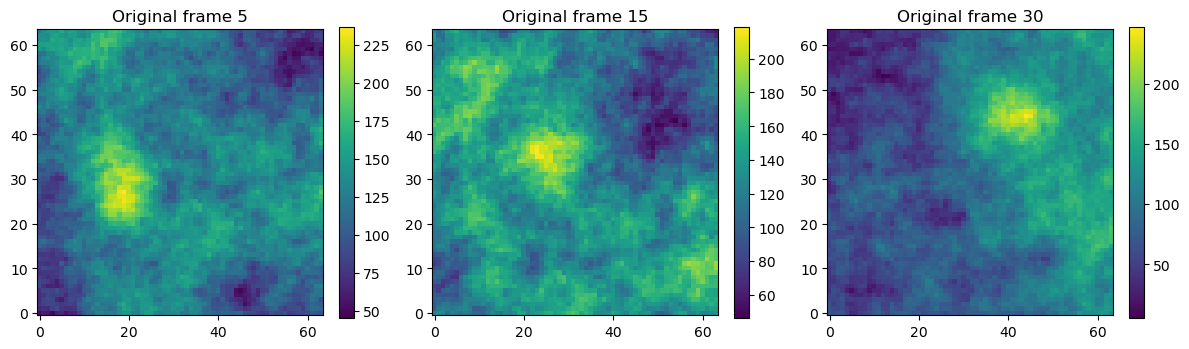

In [4]:
frame_indices = [4, 14, 29] # numpy is 0-index
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, k in zip(axes, frame_indices):
    im = ax.imshow(X[:, :, k], origin="lower")
    ax.set_title(f"Original frame {k+1}")
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()


## 2. Tensor primitives

Tucker decomposition repeatedly applies matrices along tensor modes, so implement and test these before ALS:

1. `unfold(X, mode)`
2. `mode_dot(X, M, mode)`
3. `tucker_reconstruct(core, factors)`

If
$$
Y = X\times_n M,
$$
and $X$ has mode-$n$ length $I_n$, then $M$ should have shape $(J,I_n)$, and the resulting tensor has mode-$n$ length $J$.


In [5]:
def unfold(X: np.ndarray, mode: int) -> np.ndarray:
    """Mode-n unfolding: requested mode becomes rows."""
    return np.moveaxis(X, mode, 0).reshape(X.shape[mode], -1)


def mode_dot(X: np.ndarray, M: np.ndarray, mode: int) -> np.ndarray:
    """Compute X ×_mode M.

    M.shape must be (new_mode_size, X.shape[mode]).

    """
    moved_tensor = np.moveaxis(X, mode, 0)
    moved_result = np.einsum('ij,j...->i...', M, moved_tensor)  # Einstein summation for mode-n product
    return np.moveaxis(moved_result, 0, mode)


def multi_mode_dot(X: np.ndarray, matrices: list[np.ndarray]) -> np.ndarray:
    """Apply one matrix along each mode in order."""
    Y = X
    for mode, M in enumerate(matrices):
        Y = mode_dot(Y, M, mode)
    return Y


def tucker_reconstruct(core: np.ndarray, factors: list[np.ndarray]) -> np.ndarray:
    """G ×1 U1 ×2 U2 ×3 U3."""
    return multi_mode_dot(core, factors)


### 2.1 Shape tests

Use tiny arrays before the real dataset.

For $X\in\mathbb R^{2\times3\times4}$ and $M\in\mathbb R^{5\times3}$,
$$
X\times_2 M
$$
should have shape $2\times5\times4$.

Also test that multiplying by identity matrices reproduces the original tensor.


In [6]:
X_test = np.arange(2*3*4, dtype=float).reshape(2, 3, 4)
M = np.arange(5*3, dtype=float).reshape(5, 3)
Y_test = mode_dot(X_test, M, mode=1)
assert Y_test.shape == (2, 5, 4)

X_identity = multi_mode_dot(
    X_test,
    [np.eye(2), np.eye(3), np.eye(4)],
)
assert np.allclose(X_identity, X_test)


## 3. HOSVD initialization

The lecture initializes Tucker ALS with HOSVD.

For each mode $k$:

1. Form $X_{(k)}$.
2. Compute its SVD.
3. Keep the first $R_k$ **left singular vectors** as $U^{(k)}$.

Then compute the initial core
$$
\mathcal G
=
\mathcal X
\times_1 U^{(1)\top}
\times_2 U^{(2)\top}
\times_3 U^{(3)\top}.
$$

Each factor matrix should be column-wise orthonormal.


In [7]:
def hosvd_init(X: np.ndarray, ranks: tuple[int, int, int]):
    """Return HOSVD factor matrices U^(1), U^(2), U^(3)."""
    factors = []
    for mode, R in enumerate(ranks):
        Xn = unfold(X, mode)
        U, s, Vt = np.linalg.svd(Xn, full_matrices=False)
        factors.append(U[:, :R])
    return factors


def tucker_core(X: np.ndarray, factors: list[np.ndarray]) -> np.ndarray:
    """Project X onto the factor subspaces."""
    # Apply U.T along each mode sequentially, because of associativity of mode-n products.
    core = X
    for mode, U in enumerate(factors):
        core = mode_dot(core, U.T, mode)
    return core


## 4. Tucker ALS / HOOI update

The lecture's ALS step for mode $k$ is:

1. Project $X$ along **all other modes** using their transposed factor matrices.
2. Leave mode $k$ unprojected.
3. Unfold the resulting tensor along mode $k$.
4. Set $U^{(k)}$ to the leading $R_k$ left singular vectors.
5. Repeat for all modes until convergence.

A convenient objective to monitor is the squared core norm
$$
\|\mathcal G\|_F^2,
$$
because with orthonormal factors, maximizing captured core energy is equivalent to minimizing reconstruction error.


In [8]:
def tucker_als(
    X: np.ndarray,
    ranks: tuple[int, int, int],
    *,
    max_iter: int = MAX_ITER,
    tol: float = TOL,
    verbose: bool = False,
):
    """Tucker ALS initialized by HOSVD.

    Returns
    -------
    core
    factors
    history

    --------------
    [ ] Initialize U1,U2,U3 using HOSVD.
    [ ] For each mode k:
        [ ] Start from X.
        [ ] Project along every mode j != k using Uj.T.
        [ ] Unfold the projected tensor along mode k.
        [ ] SVD that unfolding.
        [ ] Keep the first R_k left singular vectors as Uk.
    [ ] Recompute the core after each complete sweep.
    [ ] Track ||G||_F^2 or relative reconstruction error.
    [ ] Stop on small relative change.
    [ ] Verify Uk.T @ Uk ≈ I for all modes.
    """
    factors = hosvd_init(X, ranks)
    history = {"core_energy": []}

    for iteration in range(max_iter):
        for mode, R in enumerate(ranks):
            # Start from X
            X_proj = X
            # Project along every mode j != k using Uj.T
            for j, U in enumerate(factors):
                if j != mode:
                    X_proj = mode_dot(X_proj, U.T, j)
            # Unfold the projected tensor along mode k
            Xn = unfold(X_proj, mode)
            # SVD that unfolding
            U, s, Vt = np.linalg.svd(Xn, full_matrices=False)
            # Keep the first R_k left singular vectors as Uk
            factors[mode] = U[:, :R]

        # Recompute the core after each complete sweep
        core = tucker_core(X, factors)
        core_energy = np.linalg.norm(core)**2 # squared Frobenius norm as objective
        history["core_energy"].append(core_energy)

        # Stop on small relative change
        if iteration > 0:
            rel_change = abs(history["core_energy"][-1] - history["core_energy"][-2]) / history["core_energy"][-2]
            if rel_change < tol:
                break

    return core, factors, history



## 5. Validate Tucker ALS before the rank sweep

Checks:

- Factor shapes are $(I_k,R_k)$.
- $U_k^\top U_k\approx I$.
- Core shape equals `ranks`.
- Reconstructed tensor has the same shape as $X$.
- Captured core energy should not decrease materially across complete ALS sweeps.


In [9]:
def relative_error(X, X_hat):
    return np.linalg.norm(X - X_hat) / np.linalg.norm(X)


def check_orthonormal(factors, atol=1e-8):
    for mode, U in enumerate(factors):
        gram = U.T @ U
        assert np.allclose(gram, np.eye(U.shape[1]), atol=atol), (
            f"Mode {mode} factor is not orthonormal"
        )


core shape: (4, 4, 4)
relative error: 0.1527771735434373


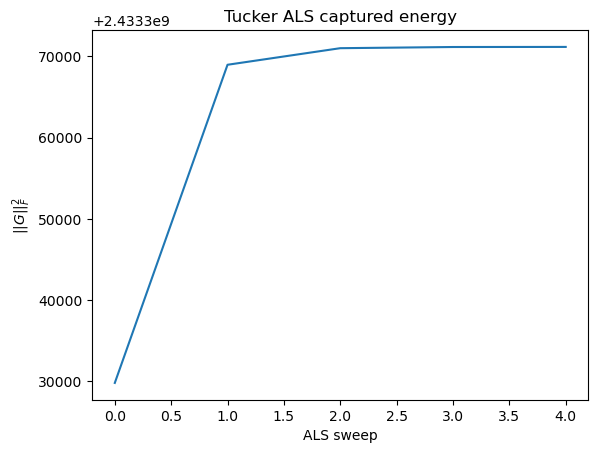

In [10]:
core, factors, history = tucker_als(X, ranks=(4, 4, 4))
check_orthonormal(factors)
X_hat = tucker_reconstruct(core, factors)
print("core shape:", core.shape)
print("relative error:", relative_error(X, X_hat))
plt.plot(history["core_energy"])
plt.xlabel("ALS sweep")
plt.ylabel(r"$||G||_F^2$")
plt.title("Tucker ALS captured energy")
plt.show()


## 6. Q4(a): rank sweep, reconstruction error, compression ratio

For each
$$
R\in\{2,4,6,8,10,15,20,25,30,40\},
$$
use
$$
(R_1,R_2,R_3)=(R,R,\min(R,40)).
$$

The relative error is
$$
\epsilon=\frac{\|X-\hat X\|_F}{\|X\|_F}.
$$

The assignment defines compression ratio as

$$
\text{compression ratio}
=
\frac{\text{number of entries in }X}
{\text{entries in core}+\text{entries in all three factor matrices}}.
$$

For dimensions $(I,J,K)$ and ranks $(R_1,R_2,R_3)$, the stored entry count is

$$
R_1R_2R_3 + IR_1 + JR_2 + KR_3.
$$


In [11]:
def compression_ratio(shape, ranks):
    I, J, K = shape
    R1, R2, R3 = ranks
    original = I * J * K
    stored = R1 * R2 * R3 + I * R1 + J * R2 + K * R3
    return original / stored


sweep = []
fits = {}

for R in R_VALUES:
    ranks = (R, R, min(R, 40))
    core, factors, history = tucker_als(X, ranks)
    X_hat = tucker_reconstruct(core, factors)
    err = relative_error(X, X_hat)
    cr = compression_ratio(X.shape, ranks)

    sweep.append({"R": R, "ranks": ranks, "error": err, "compression_ratio": cr})
    fits[ranks] = {"core": core, "factors": factors, "history": history}

for row in sweep:
    print(row)


{'R': 2, 'ranks': (2, 2, 2), 'error': np.float64(0.18169932210197595), 'compression_ratio': 476.27906976744185}
{'R': 4, 'ranks': (4, 4, 4), 'error': np.float64(0.1527771735434373), 'compression_ratio': 222.6086956521739}
{'R': 6, 'ranks': (6, 6, 6), 'error': np.float64(0.1320017492643692), 'compression_ratio': 133.8562091503268}
{'R': 8, 'ranks': (8, 8, 8), 'error': np.float64(0.11643991791530707), 'compression_ratio': 88.27586206896552}
{'R': 10, 'ranks': (10, 10, 10), 'error': np.float64(0.10665719781206222), 'compression_ratio': 61.134328358208954}
{'R': 15, 'ranks': (15, 15, 15), 'error': np.float64(0.08897404219154112), 'compression_ratio': 27.793044953350297}
{'R': 20, 'ranks': (20, 20, 20), 'error': np.float64(0.07604184624028555), 'compression_ratio': 14.422535211267606}
{'R': 25, 'ranks': (25, 25, 25), 'error': np.float64(0.06473803870088067), 'compression_ratio': 8.264312736443884}
{'R': 30, 'ranks': (30, 30, 30), 'error': np.float64(0.0532214335227006), 'compression_ratio':

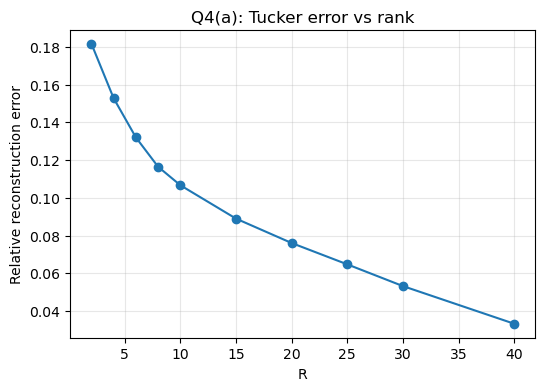

In [12]:
plt.figure(figsize=(6, 4))
plt.plot([d["R"] for d in sweep], [d["error"] for d in sweep], marker="o")
plt.xlabel("R")
plt.ylabel("Relative reconstruction error")
plt.title("Q4(a): Tucker error vs rank")
plt.grid(alpha=0.3)
plt.show()


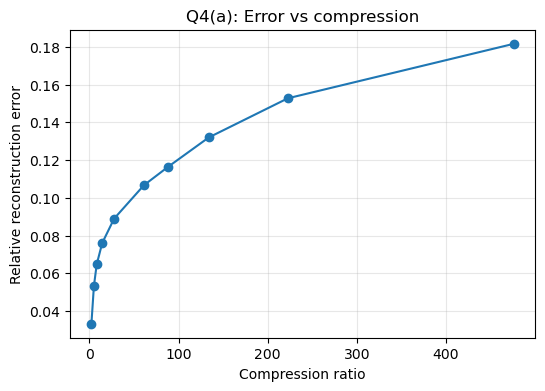

In [13]:
plt.figure(figsize=(6, 4))
plt.plot(
    [d["compression_ratio"] for d in sweep],
    [d["error"] for d in sweep],
    marker="o",
)
plt.xlabel("Compression ratio")
plt.ylabel("Relative reconstruction error")
plt.title("Q4(a): Error vs compression")
plt.grid(alpha=0.3)
plt.show()


## 7. Q4(b): orthonormal-factor error identity

You need to show
$$
\epsilon
=
\frac{\sqrt{\|X\|_F^2-\|G\|_F^2}}{\|X\|_F}.
$$

### Proof roadmap — fill this in yourself

1. Recognize $\hat X$ as the orthogonal projection of $X$ onto the multilinear subspace spanned by the columns of the factor matrices.
2. Use orthogonality of the residual and projection:
   $$
   \|X\|_F^2=\|X-\hat X\|_F^2+\|\hat X\|_F^2.
   $$
3. Because multiplying by column-orthonormal factors preserves Frobenius norm on the core coordinates, show
   $$
   \|\hat X\|_F=\|G\|_F.
   $$
4. Substitute and divide by $\|X\|_F$.

Then verify the identity numerically for ranks $(30,30,20)$.


In [ ]:
# TODO: obtain or compute the (30,30,20) decomposition.
#
# target_ranks = (30, 30, 20)
# if target_ranks in fits:
#     fit_3020 = fits[target_ranks]
#     core_3020 = fit_3020["core"]
#     factors_3020 = fit_3020["factors"]
# else:
#     core_3020, factors_3020, _ = tucker_als(X, target_ranks)
#
# check_orthonormal(factors_3020)
# X_hat_3020 = tucker_reconstruct(core_3020, factors_3020)
#
# lhs = relative_error(X, X_hat_3020)
# rhs = np.sqrt(
#     max(np.linalg.norm(X)**2 - np.linalg.norm(core_3020)**2, 0.0)
# ) / np.linalg.norm(X)
#
# print("direct relative error:", lhs)
# print("energy-identity value:", rhs)
# print("absolute difference:", abs(lhs - rhs))


## 8. Q4(c): hard threshold the $(30,30,20)$ core

For each keep fraction
$$
p\in\{0.10,0.20,0.30,0.40,0.50\},
$$
retain the $p$ fraction of core coefficients with **largest absolute value** and set all others to zero.

### Implementation details

- If the core has $N$ entries, choose exactly (or clearly define how you round) $pN$ entries.
- Rank by $|g_i|$, not by signed value.
- Keep the factor matrices fixed; only threshold the core.
- Reconstruct from the thresholded core.
- Report relative error.
- Display frames **5, 15, 30** → Python indices **4, 14, 29**.
- Also compute retained core energy $\|G_{thr}\|_F^2/\|G\|_F^2$; it makes the final interpretation much easier.


In [ ]:
def hard_threshold_core(core: np.ndarray, keep_fraction: float) -> np.ndarray:
    """Keep only the largest-|value| coefficients.

    TODO:
    1. Flatten core.
    2. Compute number to keep.
    3. Find indices of largest absolute values (np.argpartition is convenient).
    4. Zero all other entries.
    5. Reshape back to core.shape.
    """
    raise NotImplementedError


In [ ]:
KEEP_FRACTIONS = [0.10, 0.20, 0.30, 0.40, 0.50]

# TODO: threshold, reconstruct, and collect results.
# threshold_results = []
#
# for frac in KEEP_FRACTIONS:
#     G_thr = hard_threshold_core(core_3020, frac)
#     X_thr = tucker_reconstruct(G_thr, factors_3020)
#     err = relative_error(X, X_thr)
#     energy_fraction = np.linalg.norm(G_thr)**2 / np.linalg.norm(core_3020)**2
#
#     threshold_results.append({
#         "keep_fraction": frac,
#         "relative_error": err,
#         "core_energy_fraction": energy_fraction,
#         "X_hat": X_thr,
#     })
#
# for row in threshold_results:
#     print(
#         f"keep={row['keep_fraction']:.0%}, "
#         f"error={row['relative_error']:.6f}, "
#         f"core energy retained={row['core_energy_fraction']:.6f}"
#     )


In [ ]:
# TODO: display reconstructed frames 5, 15, 30 for every threshold level.
#
# frame_indices = [4, 14, 29]
#
# for row in threshold_results:
#     X_thr = row["X_hat"]
#     frac = row["keep_fraction"]
#
#     fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
#     for ax, k in zip(axes, frame_indices):
#         im = ax.imshow(X_thr[:, :, k], origin="lower")
#         ax.set_title(f"keep {frac:.0%}, frame {k+1}")
#         fig.colorbar(im, ax=ax, fraction=0.046)
#     fig.suptitle(
#         f"Thresholded Tucker reconstruction — relative error {row['relative_error']:.4f}"
#     )
#     plt.tight_layout()
#     plt.show()


## 9. Interpretation prompts for Q4(c)

Use the numerical results to answer:

- Does keeping a small fraction of the largest coefficients retain a large fraction of core energy?
- How quickly does reconstruction error fall as the keep fraction increases?
- Are major spatial structures visible even at aggressive thresholding?
- Which details disappear first?
- What does this imply about sparsity / concentration of energy in the Tucker core?

Be precise: “energy is concentrated” should be supported by the retained-energy numbers, not only by visual inspection.


## 10. Final Q4 report checklist

- [ ] `mode_dot`, HOSVD, and Tucker ALS are your own implementation.
- [ ] HOSVD is used for initialization.
- [ ] Factor orthonormality is checked numerically.
- [ ] Requested rank sweep is complete.
- [ ] Relative error and compression ratio are reported for every requested $R$.
- [ ] Both required Q4(a) plots are included.
- [ ] Q4(b) proof is written explicitly.
- [ ] Q4(b) identity is verified numerically for $(30,30,20)$.
- [ ] Q4(c) keeps coefficients by **absolute value**.
- [ ] Errors are reported for 10%, 20%, 30%, 40%, 50%.
- [ ] Frames 5, 15, 30 are displayed for each threshold level.
- [ ] Final comment is tied to measured retained core energy.
